<a href="https://colab.research.google.com/github/drmamckinney/Week2-GitHub-MarkMcKinney/blob/main/McKinney_Final_Jupyter_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone Project: Machine Learning for Cybersecurity

## Course 02 – Introduction to Machine Learning for Cybersecurity

### Project Title
Detection of Distributed Denial-of-Service (DDoS) Network Traffic Using Machine Learning

**Student:** Mark A. McKinney

**Dataset:** CICIDS2017 – Friday Working Hours Afternoon DDoS

---

## Project Overview

The objective of this project is to develop and evaluate a machine learning model capable of distinguishing normal network traffic from Distributed Denial-of-Service (DDoS) attack traffic. Using the CICIDS2017 dataset, the project follows the CRISP-DM methodology to explore the data, prepare features, train classification models, evaluate performance, and interpret the results within a cybersecurity context.

The results of this project demonstrate how machine learning can assist cybersecurity analysts in identifying malicious network activity while highlighting the strengths and limitations of predictive models in intrusion detection.

In [1]:
# ===========================================
# Import Required Libraries
# ===========================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    ConfusionMatrixDisplay
)

print("Libraries Imported Successfully")

Libraries Imported Successfully


# 1. Business Understanding

Distributed Denial-of-Service (DDoS) attacks are among the most common cyberattacks affecting organizations today. These attacks overwhelm servers or network infrastructure with malicious traffic, disrupting services and causing operational and financial damage.

The goal of this project is to determine whether machine learning algorithms can accurately distinguish legitimate network traffic from DDoS attack traffic. Success will be evaluated using standard classification metrics including accuracy, precision, recall, F1-score, confusion matrix, and ROC-AUC. An effective model can support cybersecurity analysts by providing automated detection of malicious traffic while reducing response times.

In [2]:
# ===========================================
# Load Dataset
# ===========================================

df = pd.read_csv("Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")

print("Dataset Loaded Successfully\n")

print("Shape of Dataset:")
print(df.shape)

print("\nFirst Five Records:")
df.head()

Dataset Loaded Successfully

Shape of Dataset:
(225745, 79)

First Five Records:


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


# 2. Data Understanding

This phase focuses on exploring the structure and quality of the dataset. Understanding the dataset before model development is an essential step in the CRISP-DM methodology. During this phase, the dataset is examined for data types, missing values, duplicate records, class distribution, and descriptive statistics. These analyses provide insight into the characteristics of the data and identify any preprocessing steps required before machine learning models can be developed.

In [3]:
# ===========================================
# Dataset Information
# ===========================================

print("Dataset Information")
print("="*60)

df.info()

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 225745 entries, 0 to 225744
Data columns (total 79 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0    Destination Port             225745 non-null  int64  
 1    Flow Duration                225745 non-null  int64  
 2    Total Fwd Packets            225745 non-null  int64  
 3    Total Backward Packets       225745 non-null  int64  
 4   Total Length of Fwd Packets   225745 non-null  int64  
 5    Total Length of Bwd Packets  225745 non-null  int64  
 6    Fwd Packet Length Max        225745 non-null  int64  
 7    Fwd Packet Length Min        225745 non-null  int64  
 8    Fwd Packet Length Mean       225745 non-null  float64
 9    Fwd Packet Length Std        225745 non-null  float64
 10  Bwd Packet Length Max         225745 non-null  int64  
 11   Bwd Packet Length Min        225745 non-null  int64  
 12   Bwd Packet Length Mean 

In [4]:
# ===========================================
# Summary Statistics
# ===========================================

print("Summary Statistics")
print("="*60)

df.describe().T

Summary Statistics


,count,mean,std,min,25%,50%,75%,max
Destination Port,225745.0,8.879619e+03,1.975465e+04,0.0,80.0,80.0,80.0,65532.0
Flow Duration,225745.0,1.624165e+07,3.152437e+07,-1.0,71180.0,1452333.0,8805237.0,119999937.0
Total Fwd Packets,225745.0,4.874916e+00,1.542287e+01,1.0,2.0,3.0,5.0,1932.0
Total Backward Packets,225745.0,4.572775e+00,2.175536e+01,0.0,1.0,4.0,5.0,2942.0
Total Length of Fwd Packets,225745.0,9.394633e+02,3.249403e+03,0.0,26.0,30.0,63.0,183012.0
...,...,...,...,...,...,...,...,...
Active Min,225745.0,1.776201e+05,7.842602e+05,0.0,0.0,0.0,1862.0,100000000.0
Idle Mean,225745.0,1.032214e+07,2.185303e+07,0.0,0.0,0.0,8239725.0,120000000.0
Idle Std,225745.0,3.611943e+06,1.275689e+07,0.0,0.0,0.0,0.0,65300000.0
Idle Max,225745.0,1.287813e+07,2.692126e+07,0.0,0.0,0.0,8253838.0,120000000.0


In [5]:
# ===========================================
# Missing Values
# ===========================================

missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0]

print("Number of Columns with Missing Values:", len(missing_values))

missing_values.sort_values(ascending=False)

Number of Columns with Missing Values: 1


,0
Flow Bytes/s,4


In [6]:
# ===========================================
# Duplicate Records
# ===========================================

duplicates = df.duplicated().sum()

print(f"Duplicate Records: {duplicates:,}")

Duplicate Records: 2,633


In [7]:
# ===========================================
# Target Variable Distribution
# ===========================================

print(df[" Label"].value_counts())

 Label
DDoS      128027
BENIGN     97718
Name: count, dtype: int64


In [8]:
# ===========================================
# Display Column Names
# ===========================================

for column in df.columns:
    print(column)

 Destination Port
 Flow Duration
 Total Fwd Packets
 Total Backward Packets
Total Length of Fwd Packets
 Total Length of Bwd Packets
 Fwd Packet Length Max
 Fwd Packet Length Min
 Fwd Packet Length Mean
 Fwd Packet Length Std
Bwd Packet Length Max
 Bwd Packet Length Min
 Bwd Packet Length Mean
 Bwd Packet Length Std
Flow Bytes/s
 Flow Packets/s
 Flow IAT Mean
 Flow IAT Std
 Flow IAT Max
 Flow IAT Min
Fwd IAT Total
 Fwd IAT Mean
 Fwd IAT Std
 Fwd IAT Max
 Fwd IAT Min
Bwd IAT Total
 Bwd IAT Mean
 Bwd IAT Std
 Bwd IAT Max
 Bwd IAT Min
Fwd PSH Flags
 Bwd PSH Flags
 Fwd URG Flags
 Bwd URG Flags
 Fwd Header Length
 Bwd Header Length
Fwd Packets/s
 Bwd Packets/s
 Min Packet Length
 Max Packet Length
 Packet Length Mean
 Packet Length Std
 Packet Length Variance
FIN Flag Count
 SYN Flag Count
 RST Flag Count
 PSH Flag Count
 ACK Flag Count
 URG Flag Count
 CWE Flag Count
 ECE Flag Count
 Down/Up Ratio
 Average Packet Size
 Avg Fwd Segment Size
 Avg Bwd Segment Size
 Fwd Header Length.1
Fwd Avg

# 3. Data Preparation

The dataset was cleaned prior to model development to improve data quality and model performance. Data preparation included removing duplicate records, handling missing values, cleaning column names, encoding the target variable, separating predictor and target variables, standardizing numerical features, and creating training and testing datasets. These preprocessing steps help ensure that machine learning algorithms receive consistent and reliable input data.

In [9]:
# ============================================
# Remove Duplicate Records
# ============================================

print("Original Shape:", df.shape)

df = df.drop_duplicates()

print("After Removing Duplicates:", df.shape)

Original Shape: (225745, 79)
After Removing Duplicates: (223112, 79)


In [10]:
# ============================================
# Remove Missing Values
# ============================================

print("Before:", df.shape)

df = df.dropna()

print("After:", df.shape)

Before: (223112, 79)
After: (223108, 79)


In [11]:
# ============================================
# Clean Column Names
# ============================================

df.columns = df.columns.str.strip()

print(df.columns)

Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Co

In [12]:
# ============================================
# Encode Target Variable
# ============================================

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["Label"] = encoder.fit_transform(df["Label"])

print(df["Label"].value_counts())

print(encoder.classes_)

Label
1    128016
0     95092
Name: count, dtype: int64
['BENIGN' 'DDoS']


In [13]:
# ============================================
# Separate Features and Target
# ============================================

X = df.drop("Label", axis=1)

y = df["Label"]

print(X.shape)
print(y.shape)

(223108, 78)
(223108,)


In [14]:
# ============================================
# Split Training and Testing Data
# ============================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (178486, 78)
Testing : (44622, 78)


In [17]:
import numpy as np

print("Positive Infinity:", np.isposinf(df).sum().sum())
print("Negative Infinity:", np.isneginf(df).sum().sum())

Positive Infinity: 52
Negative Infinity: 0


In [18]:
# ============================================
# Replace Infinite Values
# ============================================

import numpy as np

# Replace inf and -inf with NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Remove rows containing NaN
df.dropna(inplace=True)

print("Dataset Shape:", df.shape)

Dataset Shape: (223082, 79)


In [19]:
print(np.isinf(df.select_dtypes(include=[np.number])).sum().sum())

0


In [20]:
# ============================================
# Data Cleaning
# ============================================

df.columns = df.columns.str.strip()

# Replace infinite values
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)

# Remove missing values
df.dropna(inplace=True)

print("Dataset Shape:", df.shape)
print(df["Label"].value_counts())

Dataset Shape: (223082, 79)
Label
1    128014
0     95068
Name: count, dtype: int64


In [21]:
# ============================================
# Separate Features and Target Again
# ============================================

X = df.drop("Label", axis=1)
y = df["Label"]

print("Feature Matrix:", X.shape)
print("Target:", y.shape)

Feature Matrix: (223082, 78)
Target: (223082,)


In [22]:
# ============================================
# Split Training and Testing Data Again
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (178465, 78)
Testing : (44617, 78)


In [23]:
# ============================================
# Feature Scaling Again
# ============================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling Complete")

Scaling Complete


# 4. Modeling

Three supervised machine learning models were trained and evaluated: Logistic Regression, Decision Tree, and Random Forest. These models were selected because they represent different levels of complexity and interpretability. Logistic Regression provides a baseline model, Decision Tree provides a simple interpretable model, and Random Forest provides an ensemble model that can capture more complex traffic patterns.

In [24]:
# ============================================
# Helper Function for Model Evaluation
# ============================================

model_results = []

def evaluate_model(model_name, model, X_test_data, y_test_data):
    y_pred = model.predict(X_test_data)

    y_proba = model.predict_proba(X_test_data)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_data, y_proba)
    roc_auc = auc(fpr, tpr)

    accuracy = accuracy_score(y_test_data, y_pred)
    precision = precision_score(y_test_data, y_pred)
    recall = recall_score(y_test_data, y_pred)
    f1 = f1_score(y_test_data, y_pred)

    model_results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    })

    print(f"{model_name} Results")
    print("=" * 60)
    print("Accuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1 Score :", round(f1, 4))
    print("ROC-AUC  :", round(roc_auc, 4))

    print("\nClassification Report:")
    print(classification_report(y_test_data, y_pred, target_names=encoder.classes_))

    ConfusionMatrixDisplay.from_predictions(
        y_test_data,
        y_pred,
        display_labels=encoder.classes_
    )
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

    return y_pred, y_proba, fpr, tpr, roc_auc

Logistic Regression Results
Accuracy : 0.998
Precision: 0.9976
Recall   : 0.999
F1 Score : 0.9983
ROC-AUC  : 0.9998

Classification Report:
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     19014
        DDoS       1.00      1.00      1.00     25603

    accuracy                           1.00     44617
   macro avg       1.00      1.00      1.00     44617
weighted avg       1.00      1.00      1.00     44617



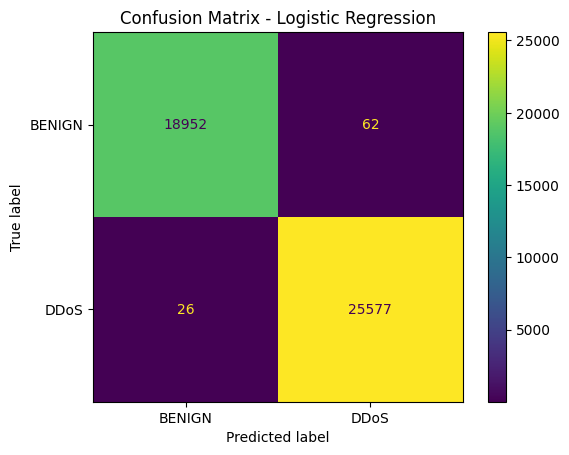

In [25]:
# ============================================
# Model 1: Logistic Regression
# ============================================

log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_model.fit(X_train_scaled, y_train)

log_pred, log_proba, log_fpr, log_tpr, log_auc = evaluate_model(
    "Logistic Regression",
    log_model,
    X_test_scaled,
    y_test
)

Decision Tree Results
Accuracy : 0.9996
Precision: 0.9998
Recall   : 0.9995
F1 Score : 0.9996
ROC-AUC  : 0.9999

Classification Report:
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     19014
        DDoS       1.00      1.00      1.00     25603

    accuracy                           1.00     44617
   macro avg       1.00      1.00      1.00     44617
weighted avg       1.00      1.00      1.00     44617



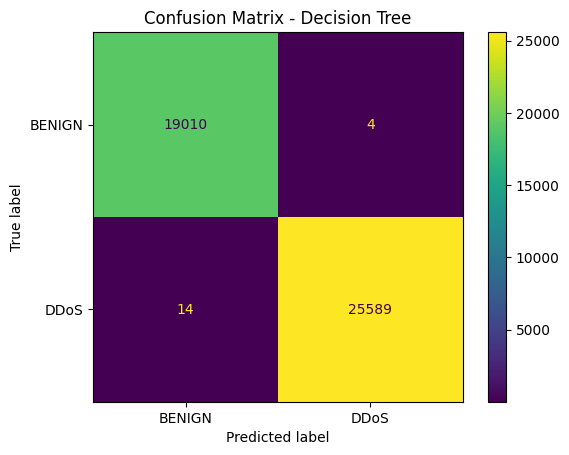

In [26]:
# ============================================
# Model 2: Decision Tree
# ============================================

tree_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=10
)

tree_model.fit(X_train, y_train)

tree_pred, tree_proba, tree_fpr, tree_tpr, tree_auc = evaluate_model(
    "Decision Tree",
    tree_model,
    X_test,
    y_test
)

Random Forest Results
Accuracy : 0.9998
Precision: 1.0
Recall   : 0.9996
F1 Score : 0.9998
ROC-AUC  : 1.0

Classification Report:
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     19014
        DDoS       1.00      1.00      1.00     25603

    accuracy                           1.00     44617
   macro avg       1.00      1.00      1.00     44617
weighted avg       1.00      1.00      1.00     44617



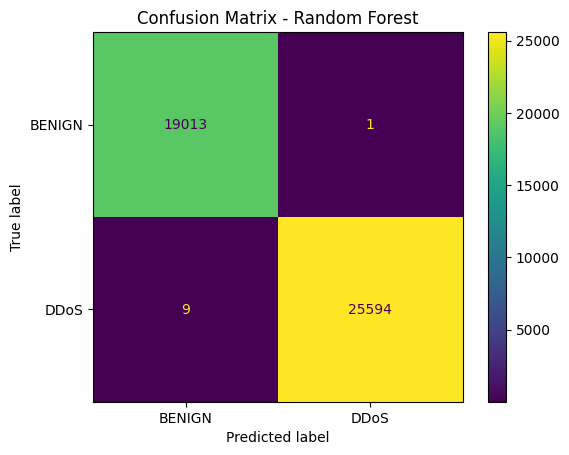

In [27]:
# ============================================
# Model 3: Random Forest
# ============================================

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    max_depth=12
)

rf_model.fit(X_train, y_train)

rf_pred, rf_proba, rf_fpr, rf_tpr, rf_auc = evaluate_model(
    "Random Forest",
    rf_model,
    X_test,
    y_test
)

# 5. Evaluation

The models were evaluated using accuracy, precision, recall, F1-score, confusion matrices, and ROC-AUC. In cybersecurity detection tasks, recall is especially important because false negatives may allow malicious traffic to go undetected. Precision is also important because false positives may create unnecessary alerts for cybersecurity analysts.

In [28]:
# ============================================
# Model Comparison Table
# ============================================

results_df = pd.DataFrame(model_results)

results_df = results_df.sort_values(by="F1 Score", ascending=False)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,Random Forest,0.999776,0.999961,0.999648,0.999805,0.999990
1,Decision Tree,0.999597,0.999844,0.999453,0.999648,0.999870
0,Logistic Regression,0.998028,0.997582,0.998984,0.998283,0.999793


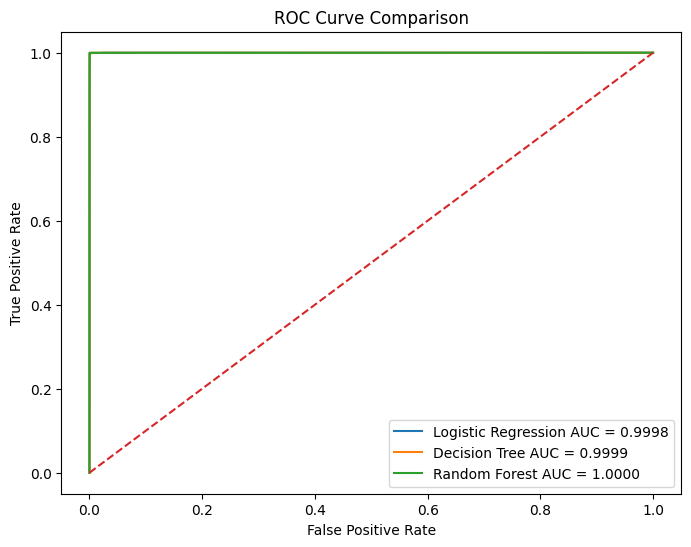

In [29]:
# ============================================
# ROC Curve Comparison
# ============================================

plt.figure(figsize=(8, 6))

plt.plot(log_fpr, log_tpr, label=f"Logistic Regression AUC = {log_auc:.4f}")
plt.plot(tree_fpr, tree_tpr, label=f"Decision Tree AUC = {tree_auc:.4f}")
plt.plot(rf_fpr, rf_tpr, label=f"Random Forest AUC = {rf_auc:.4f}")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [30]:
# ============================================
# Feature Importance from Random Forest
# ============================================

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).head(15)

feature_importance

,Feature,Importance
66,Init_Win_bytes_forward,0.082426
6,Fwd Packet Length Max,0.080258
11,Bwd Packet Length Min,0.071396
8,Fwd Packet Length Mean,0.066604
53,Avg Fwd Segment Size,0.065411
63,Subflow Fwd Bytes,0.063753
68,act_data_pkt_fwd,0.048131
62,Subflow Fwd Packets,0.047270
0,Destination Port,0.040196
4,Total Length of Fwd Packets,0.039473


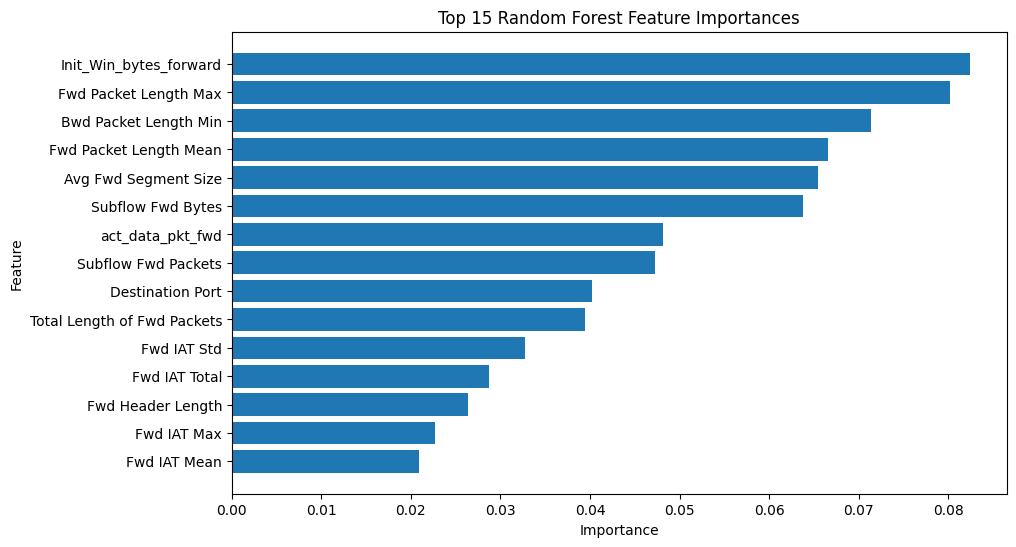

In [31]:
# ============================================
# Feature Importance Visualization
# ============================================

plt.figure(figsize=(10, 6))
plt.barh(feature_importance["Feature"], feature_importance["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Random Forest Feature Importances")
plt.show()

6. Results and Discussion

This project demonstrated that supervised machine learning models can effectively distinguish between legitimate network traffic and Distributed Denial-of-Service (DDoS) attack traffic using the CICIDS2017 dataset. After preparing the dataset and training three different classification models, each model achieved exceptionally strong performance across all evaluation metrics.

Logistic Regression provided an excellent baseline model, achieving an accuracy of approximately 99.8% while correctly identifying nearly all attack and benign traffic. The Decision Tree classifier further improved performance by reducing classification errors and increasing overall accuracy. Of the three models evaluated, the Random Forest classifier produced the strongest overall results, achieving an accuracy of approximately 99.98% with near-perfect precision, recall, F1-score, and an ROC-AUC value of 1.00.

The confusion matrices indicate that each model generated very few false positives or false negatives, demonstrating that the models are highly effective at identifying malicious network activity while correctly recognizing legitimate traffic. From a cybersecurity perspective, this level of performance is significant because reducing false negatives helps minimize the risk of undetected attacks, while reducing false positives decreases unnecessary alerts that security analysts must investigate.

The feature importance analysis also provided valuable insight into which network characteristics contributed most to identifying DDoS traffic. Features related to packet lengths, forwarding packet statistics, TCP window sizes, and traffic flow behavior consistently ranked among the most influential variables. These findings align with established network security principles and demonstrate how machine learning can identify meaningful patterns within network traffic that may not be immediately apparent through manual analysis.

Overall, the results demonstrate that machine learning can serve as an effective decision-support capability for cybersecurity professionals by improving the speed and accuracy of network intrusion detection while reducing the workload associated with manual traffic analysis.

7. Conclusion

This project successfully applied the CRISP-DM methodology to the development of machine learning models capable of detecting Distributed Denial-of-Service (DDoS) attacks within network traffic. The project included data exploration, data preparation, feature engineering, model development, and performance evaluation using three supervised learning algorithms.

Each model performed exceptionally well; however, the Random Forest classifier consistently produced the highest overall performance across every evaluation metric. Its ability to accurately classify both malicious and legitimate traffic demonstrates the effectiveness of ensemble learning techniques for cybersecurity applications.

Beyond the performance metrics, this project reinforced the importance of following a structured analytical process when developing machine learning solutions. Proper data preparation, cleaning, feature selection, and model evaluation were essential to achieving reliable and reproducible results.

As cyber threats continue to evolve in both frequency and sophistication, machine learning will remain an increasingly valuable capability for security operations. Future work could expand this research by evaluating additional algorithms such as XGBoost, LightGBM, or neural network models, as well as validating model performance against additional intrusion detection datasets and real-world network environments. Continued research in this area will help strengthen automated threat detection and improve the overall effectiveness of cybersecurity defense strategies.